# XGB 06 — Interpretation

Inspect generated feature importance and residual diagnostics without retraining.

In [3]:
# Import libraries
from pathlib import Path
import sys
import json
import pandas as pd

import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / "reports" / "modeling" / "forecasting" / "xgboost"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "modeling" / "forecasting" / "xgboost"

REPORTS_DIR, OUTPUTS_DIR

(WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/reports/modeling/forecasting/xgboost'),
 WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/outputs/modeling/forecasting/xgboost'))

In [ ]:
# Get model features importance 
importance = pd.read_csv(REPORTS_DIR / "XGB_06_feature_importance.csv").head(15)
predictions = pd.read_parquet(OUTPUTS_DIR / "xgboost_validation_predictions.parquet")
predictions["forecast_origin"] = pd.to_datetime(predictions["forecast_origin"])
predictions["residual"] = predictions["actual"] - predictions["predicted"]

# Display  features importance
display(importance)


,feature,importance
0,target_lag_24h,0.653876
1,target_lag_48h,0.186597
2,target_lag_168h,0.053721
3,origin__Temp (°C),0.007914
4,origin_rolling_mean_24h,0.006871
5,fsa_L4T,0.006178
6,origin_rolling_std_24h,0.005154
7,target_hour,0.005063
8,target_hour_cos,0.004892
9,target_is_weekend,0.004432


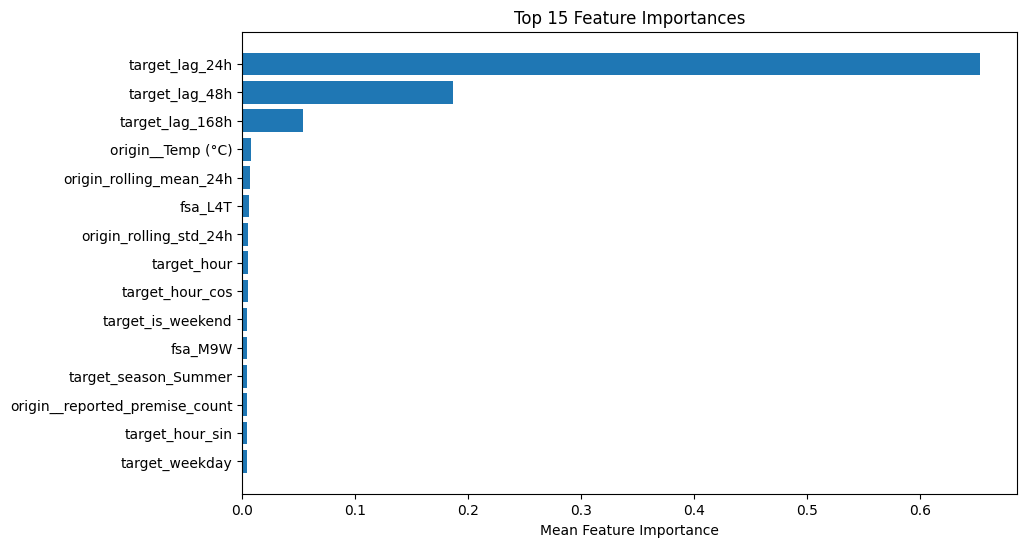

In [5]:
# Top 15 Feature Importances
plt.figure(figsize=(10, 6))
plot_data = importance.sort_values("importance")
plt.barh(plot_data["feature"], plot_data["importance"])
plt.xlabel("Mean Feature Importance")
plt.title("Top 15 Feature Importances")
plt.show()


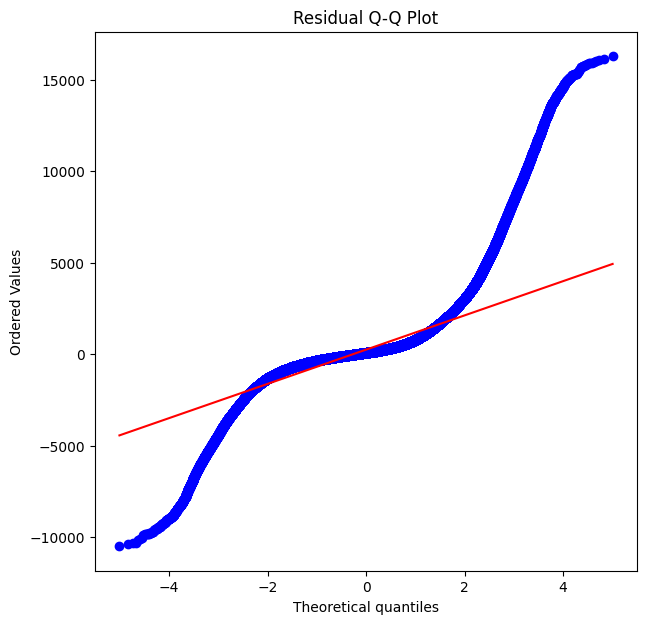

In [6]:
# Residual Q-Q Plot
plt.figure(figsize=(7, 7))
stats.probplot(predictions["residual"].dropna(), dist="norm", plot=plt)
plt.title("Residual Q-Q Plot")
plt.show()


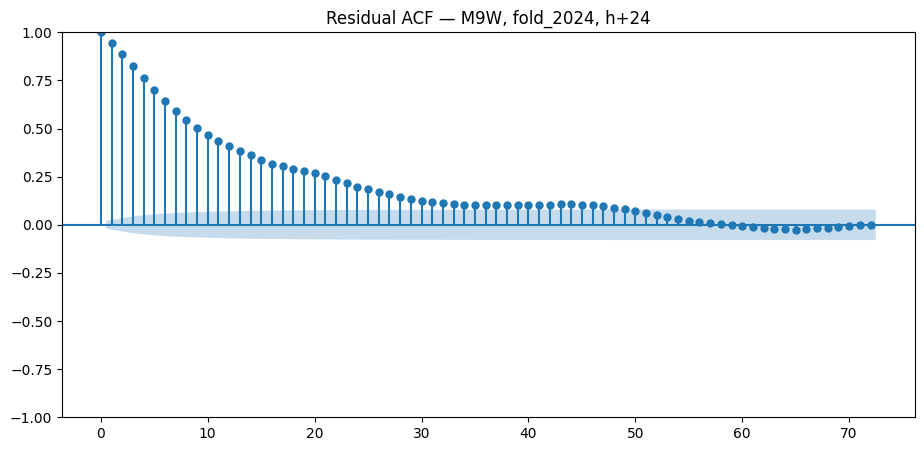

In [7]:
# Residual ACF
acf_series = (
    predictions
    .query("fold == 'fold_2024' and fsa == 'M9W' and horizon == 24")
    .sort_values("forecast_origin")["residual"]
    .dropna()
)
plt.figure(figsize=(11, 5))
plot_acf(acf_series, lags=72, ax=plt.gca())
plt.title("Residual ACF — M9W, fold_2024, h+24")
plt.show()


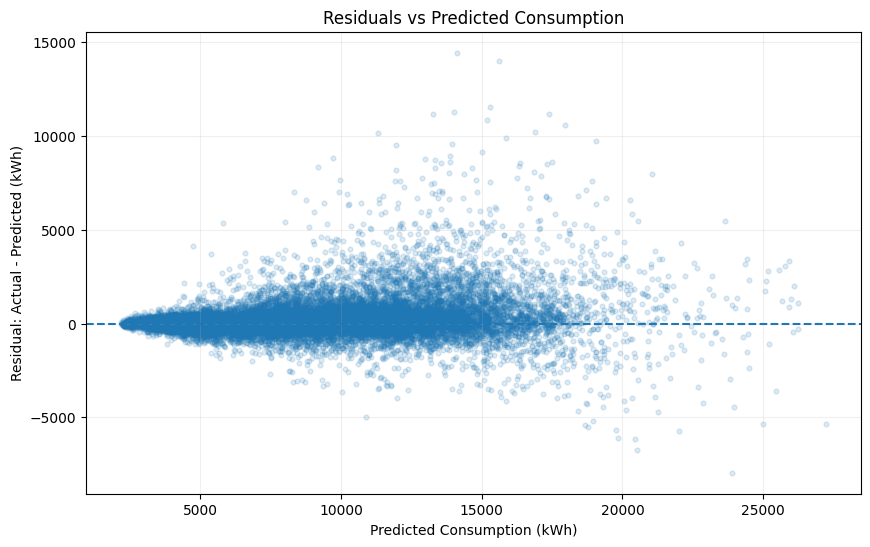

In [8]:
# Residuals vs Predicted Consumption
sample = predictions.sample(n=min(20000, len(predictions)), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample["predicted"], sample["residual"], alpha=0.15, s=12)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Consumption (kWh)")
plt.ylabel("Residual: Actual - Predicted (kWh)")
plt.title("Residuals vs Predicted Consumption")
plt.grid(alpha=0.2)
plt.show()
